예제 6.9 CNN(CIFAR-10) 텐서플로

In [ ]:
# 예제 6.9 CIFAR-10 CNN

#셋업
import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense
from tensorflow.keras.layers import Flatten, Dropout
from tensorflow.keras.datasets import cifar10
import numpy as np
import matplotlib.pyplot as plt

# 데이터셋 준비
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(x_train.shape, y_train.shape)   # 학습 데이터 shape 확인
print(x_test.shape, y_test.shape)     # 테스트 데이터 shape 확인

170498071/170498071 [==============================] - 4s 0us/step
(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


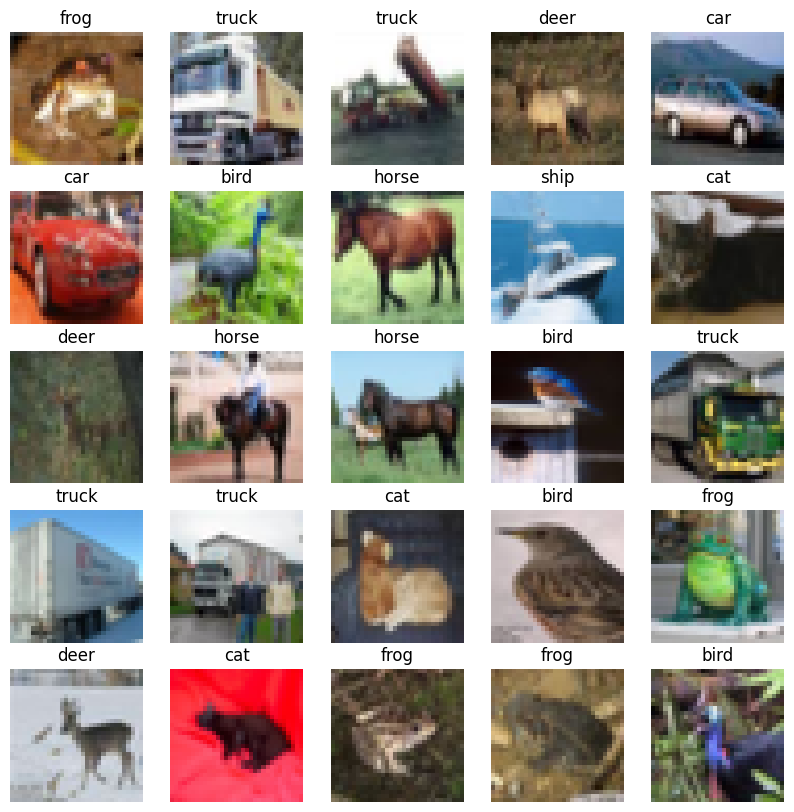

In [ ]:
# 학습 데이터 시각화
class_names = ["plane", "car", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')

plt.show()

In [ ]:
# 데이터 정규화
x_train, x_test = x_train / 255., x_test / 255.

In [ ]:
# 모델 생성
model = Sequential(name='CIFAR10_CNN_Model')

# 특징 추출 신경망
model.add(Conv2D(32, kernel_size=3, padding='same', activation='relu',
                 input_shape=(32, 32, 3)))
model.add(Conv2D(32, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(64, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Conv2D(128, kernel_size=3, padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=2))

# 분류 신경망
model.add(Flatten())
model.add(Dropout(0.5))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

In [ ]:
# 모델 구조 요약
model.summary()

Model: "CIFAR10_CNN_Model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 conv2d_1 (Conv2D)           (None, 32, 32, 32)        9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 16, 16, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 8, 8, 64)         0         
 2D)                                             

In [ ]:
# 모델 컴파일
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 모델 학습
early_stopping_cb = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3)

history = model.fit(x_train, y_train, batch_size=32, epochs=50,
                    verbose=1, validation_split=0.2,
                    callbacks=early_stopping_cb)

Epoch 1/50
1250/1250 [==============================] - 21s 6ms/step - loss: 1.8007 - accuracy: 0.3298 - val_loss: 1.3968 - val_accuracy: 0.4818
Epoch 2/50
1250/1250 [==============================] - 8s 6ms/step - loss: 1.3782 - accuracy: 0.4960 - val_loss: 1.1766 - val_accuracy: 0.5728
Epoch 3/50
1250/1250 [==============================] - 8s 6ms/step - loss: 1.2145 - accuracy: 0.5637 - val_loss: 1.0520 - val_accuracy: 0.6252
Epoch 4/50
1250/1250 [==============================] - 7s 6ms/step - loss: 1.1167 - accuracy: 0.6030 - val_loss: 0.9671 - val_accuracy: 0.6563
Epoch 5/50
1250/1250 [==============================] - 8s 6ms/step - loss: 1.0319 - accuracy: 0.6371 - val_loss: 0.9599 - val_accuracy: 0.6583
Epoch 6/50
1250/1250 [==============================] - 8s 7ms/step - loss: 0.9792 - accuracy: 0.6542 - val_loss: 0.9941 - val_accuracy: 0.6543
Epoch 7/50
1250/1250 [==============================] - 8s 6ms/step - loss: 0.9322 - accuracy: 0.6711 - val_loss: 0.8419 - val_accuracy

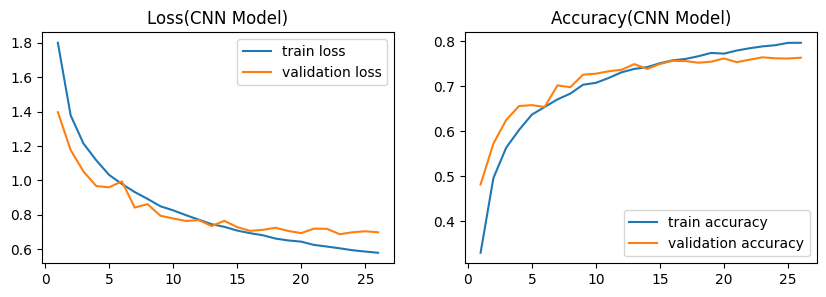

In [ ]:
# 학습 결과 시각화
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 3))

ax = axs[0]
ax.plot(range(1, len(history.history["loss"]) + 1),
        history.history['loss'], label='train loss')
ax.plot(range(1, len(history.history["val_loss"]) + 1),
        history.history['val_loss'], label='validation loss')
ax.set_title('Loss(CNN Model)')
ax.legend(loc='best')

ax = axs[1]
ax.plot(range(1, len(history.history["accuracy"]) + 1),
        history.history['accuracy'], label='train accuracy')
ax.plot(range(1, len(history.history["val_accuracy"]) + 1),
        history.history['val_accuracy'], label='validation accuracy')
ax.set_title('Accuracy(CNN Model)')
ax.legend(loc='best')

plt.show()

In [ ]:
# 모델 평가
model.evaluate(x_test, y_test)

313/313 [==============================] - 1s 3ms/step - loss: 0.7197 - accuracy: 0.7634


[0.7196797132492065, 0.7634000182151794]

1/1 [==============================] - 0s 289ms/step


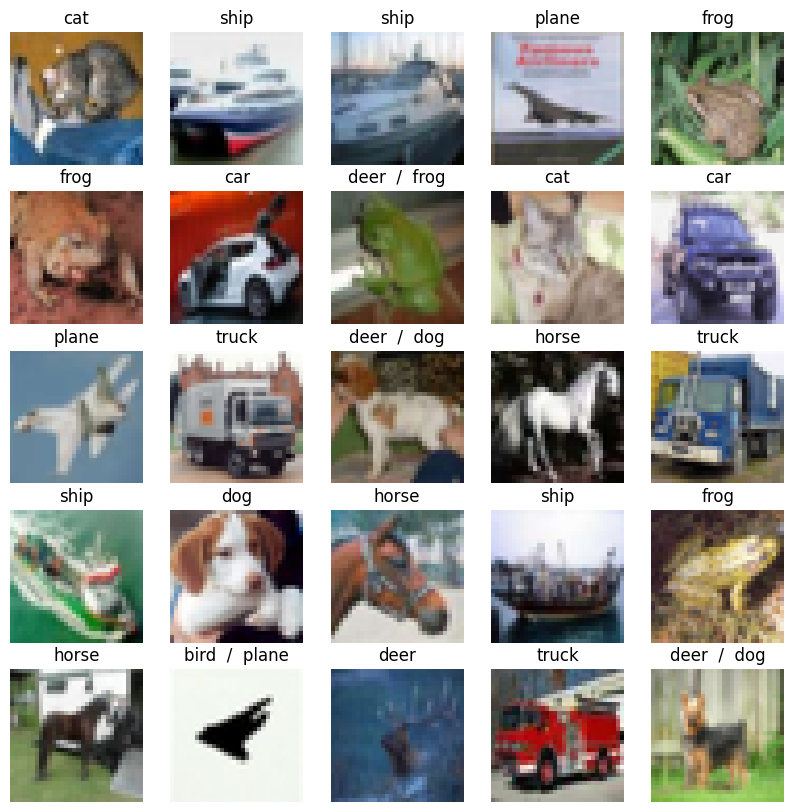

In [ ]:
# 모델 예측 결과 시각화
x = x_test[:25]
y_pred = np.argmax(model.predict(x), axis=1)

plt.figure(figsize=(10 ,10))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(x_test[i])
    if y_pred[i] != y_test[i]:
       plt.title(class_names[int(y_pred[i])] + '  /  '
                 + class_names[int(y_test[i])])
    else:
       plt.title(class_names[int(y_pred[i])])
    plt.axis('off')

plt.show()